In [38]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# Path (change if needed)
train_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
test_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)  # (60000, 785)

(60000, 785)


In [39]:
class FashionDataset(Dataset):
    def __init__(self, df):
        self.labels = df.iloc[:, 0].values
        self.images = df.iloc[:, 1:].values / 255.0  # normalize

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        img = img.view(1, 28, 28)  # reshape
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [40]:
train_dataset = FashionDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [41]:
def add_noise(x):
    noise = torch.randn_like(x) * 0.5
    return torch.clamp(x + noise, 0., 1.)

In [42]:
import torch.nn as nn

class DAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(20):
    for img, _ in train_loader:
        img = img.to(device)
        noisy = add_noise(img).to(device)

        output = model(noisy)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0249
Epoch 2, Loss: 0.0202
Epoch 3, Loss: 0.0223
Epoch 4, Loss: 0.0180
Epoch 5, Loss: 0.0184
Epoch 6, Loss: 0.0163
Epoch 7, Loss: 0.0163
Epoch 8, Loss: 0.0141
Epoch 9, Loss: 0.0153
Epoch 10, Loss: 0.0166
Epoch 11, Loss: 0.0148
Epoch 12, Loss: 0.0155
Epoch 13, Loss: 0.0175
Epoch 14, Loss: 0.0150
Epoch 15, Loss: 0.0142
Epoch 16, Loss: 0.0136
Epoch 17, Loss: 0.0152
Epoch 18, Loss: 0.0161
Epoch 19, Loss: 0.0155
Epoch 20, Loss: 0.0146


In [44]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, 20)
        self.fc_logvar = nn.Linear(256, 20)

        self.fc2 = nn.Linear(20, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [45]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 784), reduction='sum'
    )
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [46]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    for img, _ in train_loader:
        img = img.to(device)

        recon, mu, logvar = model(img)
        loss = vae_loss(recon, img, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 25546.6270
Epoch 2, Loss: 24519.9609
Epoch 3, Loss: 24587.6445
Epoch 4, Loss: 24389.5020
Epoch 5, Loss: 24891.5195
Epoch 6, Loss: 24013.0801
Epoch 7, Loss: 23351.6914
Epoch 8, Loss: 24345.2324
Epoch 9, Loss: 24053.5859
Epoch 10, Loss: 23624.1777
Epoch 11, Loss: 23985.8184
Epoch 12, Loss: 22911.0195
Epoch 13, Loss: 21674.5879
Epoch 14, Loss: 22857.9473
Epoch 15, Loss: 22712.4062
Epoch 16, Loss: 24672.5156
Epoch 17, Loss: 22365.1953
Epoch 18, Loss: 23145.1348
Epoch 19, Loss: 23340.0215
Epoch 20, Loss: 22734.8926


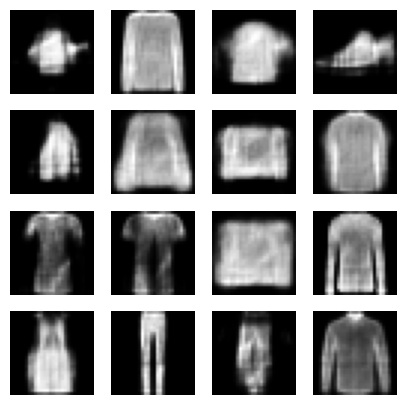

In [47]:
import matplotlib.pyplot as plt

with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = model.decode(z).cpu()

plt.figure(figsize=(5,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()